In [1]:
import numpy as np
from pythtb import TBModel, WFArray, Mesh, Lattice
from pythtb.models.haldane import haldane

import matplotlib.pyplot as plt

In [2]:
# tight-binding parameters
delta = 1
t = 1
t2 = -0.3

model = haldane(delta, t, t2)
lat = model.lattice
print(lat)

----------------------------------------
       Lattice structure report         
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
number of orbitals          = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
No symmetry operations registered.

----------------------------------------


(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

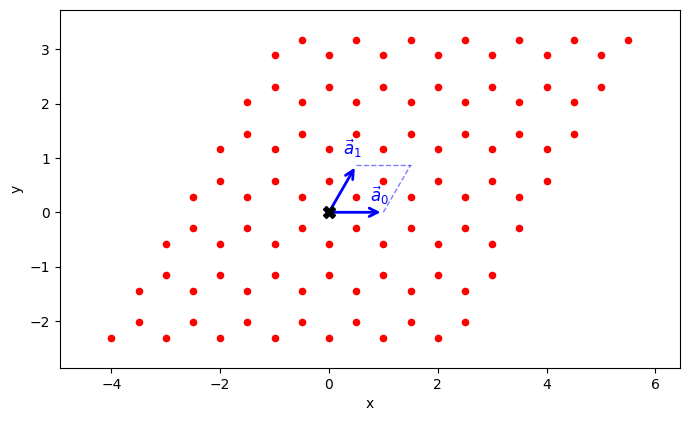

In [16]:
lat.visualize(n_cells=4)

In [4]:
# --- lattice & symmetry: register C3 in reduced coordinates (2D periodic) ---
# Honeycomb in reduced basis: a common integer C3 block is [[0,-1],[1,-1]]
# (Acts on reduced real-space coords; k transforms with R^{-T}.)
C3 = np.array([[0, -1],
               [1, -1]], float)

lat.add_symmetry_operation(R=np.block([[C3]]), t=[0,0], label="C3z")  # det=+1, no TR
print(lat)
lat.check_symmetry()

----------------------------------------
       Lattice structure report         
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
number of orbitals          = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
Symmetry operations (reduced-coord representation):
  # 0 [C3z]  R=
[[ 0.000, -1.000],
 [ 1.000, -1.000]]
           t=[ 0.000,  0.000]

----------------------------------------


{'lattice_ok': True,
 'orbitals_ok': False,
 'bad_ops_lattice': [],
 'bad_ops_orbitals': [0]}

In [26]:
Nk = (20, 20)
mesh = Mesh(dim_k=2, axis_types=['k','k'])
mesh.build_grid(shape=Nk)            # reduced k in [0,1)^2
mesh_cart = mesh.grid @ model.recip_lat_vecs
KX, KY = mesh_cart[..., 0], mesh_cart[..., 1]
kpts = mesh.flat                     # (Nkx*Nky, 2)

In [24]:
K_ir, w_ir, map_full = lat.reduce_kmesh(kpts)   # reps, normalized weights, map (len(kpts),)

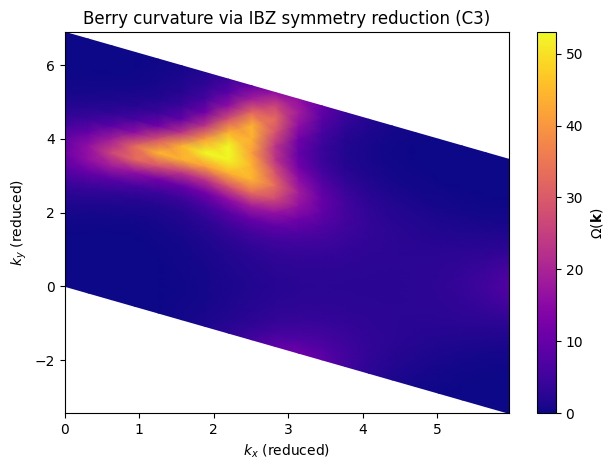

In [29]:
# --- compute Berry curvature only on the IBZ ---
# Assumes your TBModel exposes a Kubo-like curvature call that vectorizes over kpts.
# If signature differs, adapt accordingly.
# occ_idxs=[0] -> lowest band occupied; returns array shaped (Nk_ir, dim_k, dim_k) or similar
bflux_ir = model.berry_curvature(K_ir, occ_idxs=[0])[0, 1]  # (Nk_ir,)
# If your function returns [bands, dim, dim], adjust indexing accordingly.

# --- expand back to full BZ ---
bflux_full = bflux_ir[map_full]                  # no sign flips for pure C3 (det=+1, no TR)

# --- plot ---
bflux_grid = bflux_full.reshape(Nk)

plt.figure()
im = plt.pcolormesh(KX, KY, bflux_grid.real, shading='gouraud', cmap='plasma')
plt.colorbar(label=r'$\Omega(\mathbf{k})$')
plt.xlabel(r'$k_x$ (reduced)')
plt.ylabel(r'$k_y$ (reduced)')
plt.title('Berry curvature via IBZ symmetry reduction (C3)')
plt.tight_layout()
plt.show()

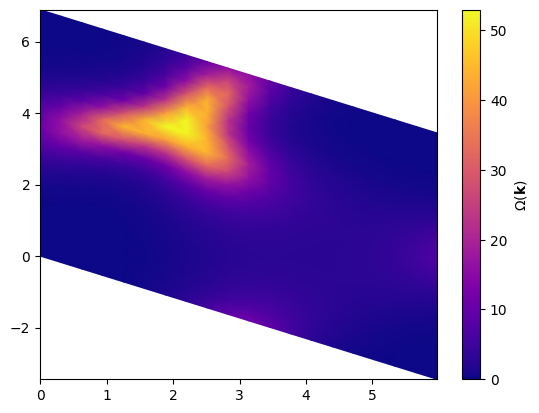

In [27]:
bflux_kubo = model.berry_curvature(kpts, occ_idxs=[0])[0, 1].reshape(mesh.shape_k)
im = plt.pcolormesh(KX, KY, bflux_kubo.real, cmap='plasma', shading='gouraud')
plt.colorbar(label=r'$\Omega(\mathbf{k})$')